# Week 1 — Explore the Data

**What you will do this week:**
1. Load the data into Python and take a first look
2. Answer basic questions using pandas
3. Write simple SQL queries using SQLite
4. Produce your first charts

**By the end of this notebook you should be able to answer:**
- How many facilities are in the dataset?
- Which medicine has the highest stock-out rate?
- Which zone has the lowest average days of stock?

---

## 1. Load the data

We have two CSV files:
- `facilities.csv` — one row per health facility (name, type, zone, lead time)
- `stock.csv` — one row per facility, per medicine, per month

Run the cell below to load them.

In [19]:
import pandas as pd

facilities = pd.read_csv('../data/facilities.csv')
stock      = pd.read_csv('../data/stock.csv')

print('Facilities:', len(facilities), 'rows')
print('Stock records:', len(stock), 'rows')

Facilities: 50 rows
Stock records: 2149 rows


## 2. Take a first look

`.head()` shows the first 5 rows. `.info()` shows column names and data types.

In [20]:
facilities.head()

,facility_id,facility_name,facility_type,zone,lead_time_days
0,ETH001,Facility 1,Health Centre,SNNPR,21
1,ETH002,Facility 2,Hospital,Oromia,37
2,ETH003,Facility 3,Health Post,SNNPR,13
3,ETH004,Facility 4,Health Centre,SNNPR,26
4,ETH005,Facility 5,Health Post,Tigray,10


In [21]:
stock.head()

,facility_id,facility_type,zone,lead_time_days,medicine,month,stock_on_hand,consumption,resupply,days_of_stock,stockout
0,ETH001,Health Centre,SNNPR,21,Oxytocin,2024-01,72.0,27,0,80.0,0
1,ETH001,Health Centre,SNNPR,21,Oxytocin,2024-02,44.0,28,0,47.1,0
2,ETH001,Health Centre,SNNPR,21,Oxytocin,2024-03,24.0,20,0,36.0,0
3,ETH001,Health Centre,SNNPR,21,Oxytocin,2024-04,68.0,25,69,81.6,0
4,ETH001,Health Centre,SNNPR,21,Oxytocin,2024-05,40.0,28,0,42.9,0


In [22]:
stock.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   facility_id     2149 non-null   str    
 1   facility_type   2149 non-null   str    
 2   zone            2149 non-null   str    
 3   lead_time_days  2149 non-null   int64  
 4   medicine        2149 non-null   str    
 5   month           2149 non-null   str    
 6   stock_on_hand   2149 non-null   float64
 7   consumption     2149 non-null   int64  
 8   resupply        2149 non-null   int64  
 9   days_of_stock   2149 non-null   float64
 10  stockout        2149 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 184.8 KB


## 3. Basic counts and summaries

`.value_counts()` is your best friend for counting categories.

In [23]:
# How many facilities of each type?
facilities['facility_type'].value_counts()

facility_type
Health Centre    27
Health Post      20
Hospital          3
Name: count, dtype: int64

In [24]:
# How many facilities per zone?
facilities['zone'].value_counts()

zone
Amhara    15
SNNPR     14
Tigray    12
Oromia     9
Name: count, dtype: int64

In [25]:
# What medicines are in the dataset?
stock['medicine'].unique()

<StringArray>
['Oxytocin', 'ORS/Zinc', 'Artemether-Lumefantrine', 'Magnesium Sulphate']
Length: 4, dtype: str

In [26]:
# Basic statistics for numeric columns
stock[['stock_on_hand', 'consumption', 'days_of_stock']].describe()

,stock_on_hand,consumption,days_of_stock
count,2149.000000,2149.000000,2149.000000
mean,38.743602,20.362029,61.698092
std,48.806843,20.232107,46.612317
min,0.000000,0.000000,0.000000
25%,10.000000,6.000000,26.400000
50%,22.000000,19.000000,54.000000
75%,55.000000,26.000000,87.500000
max,492.000000,150.000000,180.000000


## 4. Answer questions with groupby

`groupby` lets you split the data by a category and calculate something for each group.

**Pattern:** `df.groupby('column')['other_column'].mean()`

In [27]:
# Average days of stock by medicine
stock.groupby('medicine')['days_of_stock'].mean().sort_values()

medicine
Artemether-Lumefantrine    55.894485
ORS/Zinc                   63.096415
Oxytocin                   63.481937
Magnesium Sulphate         64.408364
Name: days_of_stock, dtype: float64

In [28]:
# Stock-out rate by medicine
# (stockout column is 1 if stocked out, 0 if not — so the mean gives us the rate)
stock.groupby('medicine')['stockout'].mean().sort_values(ascending=False)

medicine
Artemether-Lumefantrine    0.125000
ORS/Zinc                   0.086792
Oxytocin                   0.081937
Magnesium Sulphate         0.063197
Name: stockout, dtype: float64

In [29]:
# Average days of stock by zone
stock.groupby('zone')['days_of_stock'].mean().sort_values()

zone
Tigray    59.763672
Oromia    61.245570
Amhara    61.440250
SNNPR     63.918469
Name: days_of_stock, dtype: float64

## 5. SQL queries with SQLite

We can load our data into a temporary SQLite database and query it with SQL.
This is good practice for when you work with real databases.

In [30]:
import sqlite3

# Create an in-memory database and load our tables into it
conn = sqlite3.connect(':memory:')
facilities.to_sql('facilities', conn, index=False, if_exists='replace')
stock.to_sql('stock', conn, index=False, if_exists='replace')

print('Tables loaded into SQLite.')

Tables loaded into SQLite.


In [31]:
# SQL query 1: stock-out rate by medicine
query = """
SELECT
    medicine,
    COUNT(*)                            AS total_records,
    SUM(stockout)                       AS total_stockouts,
    ROUND(AVG(stockout) * 100, 1)       AS stockout_rate_pct
FROM stock
GROUP BY medicine
ORDER BY stockout_rate_pct DESC
"""
pd.read_sql(query, conn)

,medicine,total_records,total_stockouts,stockout_rate_pct
0,Artemether-Lumefantrine,544,68,12.5
1,ORS/Zinc,530,46,8.7
2,Oxytocin,537,44,8.2
3,Magnesium Sulphate,538,34,6.3


In [32]:
# SQL query 2: average days of stock by zone and facility type
query = """
SELECT
    zone,
    facility_type,
    ROUND(AVG(days_of_stock), 1)  AS avg_days_of_stock,
    COUNT(DISTINCT facility_id)   AS num_facilities
FROM stock
GROUP BY zone, facility_type
ORDER BY avg_days_of_stock
"""
pd.read_sql(query, conn)

,zone,facility_type,avg_days_of_stock,num_facilities
0,Amhara,Hospital,40.6,1
1,Oromia,Hospital,52.0,2
2,SNNPR,Health Centre,59.2,9
3,Tigray,Health Post,59.6,7
4,Tigray,Health Centre,60.0,5
5,Oromia,Health Centre,61.2,4
6,Amhara,Health Centre,62.3,9
7,Amhara,Health Post,63.4,5
8,Oromia,Health Post,67.5,3
9,SNNPR,Health Post,72.4,5


In [33]:
# SQL query 3: which facilities have the most stock-outs?
query = """
SELECT
    facility_id,
    facility_type,
    zone,
    SUM(stockout)  AS total_stockout_months
FROM stock
GROUP BY facility_id, facility_type, zone
ORDER BY total_stockout_months DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,facility_id,facility_type,zone,total_stockout_months
0,ETH002,Hospital,Oromia,13
1,ETH012,Hospital,Amhara,9
2,ETH017,Health Post,Tigray,7
3,ETH029,Health Centre,SNNPR,7
4,ETH036,Health Post,Amhara,7
5,ETH045,Health Post,Tigray,7
6,ETH049,Health Post,Tigray,7
7,ETH003,Health Post,SNNPR,6
8,ETH005,Health Post,Tigray,6
9,ETH024,Health Post,Tigray,6


## 6. Your first charts

We use `matplotlib` for simple charts. The pattern is always:
1. Prepare the data (usually a `groupby`)
2. Call `.plot()`

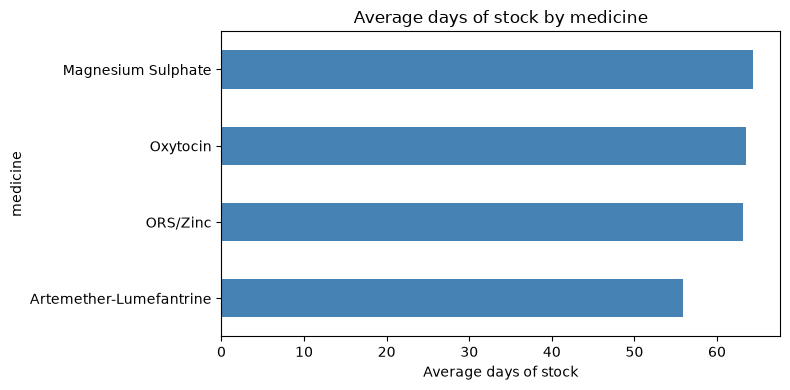

In [34]:
import matplotlib.pyplot as plt

# Bar chart: average days of stock by medicine
avg_dos = stock.groupby('medicine')['days_of_stock'].mean().sort_values()

avg_dos.plot(kind='barh', figsize=(8, 4), color='steelblue')
plt.xlabel('Average days of stock')
plt.title('Average days of stock by medicine')
plt.tight_layout()
plt.show()

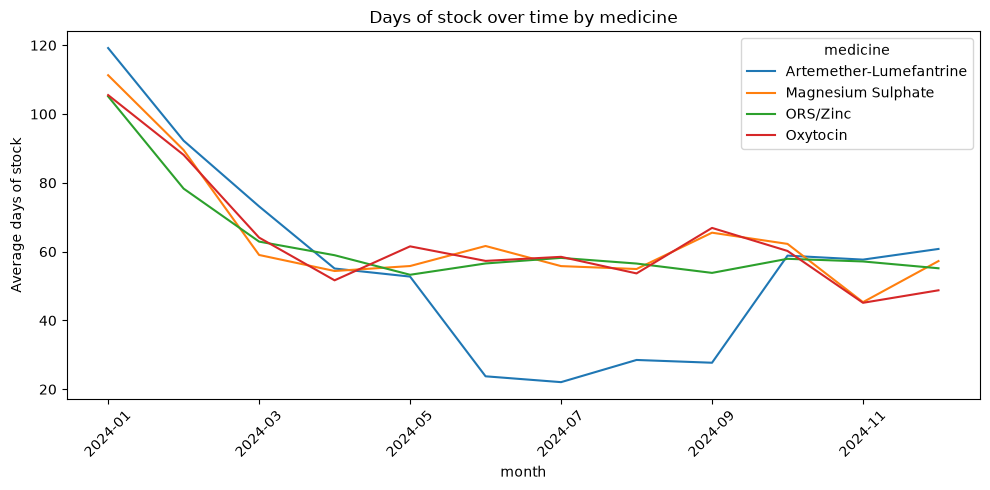

In [35]:
# Line chart: average days of stock over time for each medicine
trend = stock.groupby(['month', 'medicine'])['days_of_stock'].mean().unstack()

trend.plot(figsize=(10, 5))
plt.ylabel('Average days of stock')
plt.title('Days of stock over time by medicine')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## ✅ Week 1 checklist

Before moving to Week 2, make sure you can answer these:

- [ ] How many total stock records are in the dataset?
- [ ] Which medicine has the highest average stock-out rate?
- [ ] Which zone has the lowest average days of stock?
- [ ] What does the `stockout` column contain — what do 0 and 1 mean?
- [ ] What is the difference between `stock_on_hand` and `days_of_stock`?

Write your answers in the cell below as comments.

In [36]:
# Your answers here:
# Total stock records: 2149 rows
# Medicine with highest stock-out rate: Artemether Lumefantrine
# Zone with lowest avg days of stock: Artemether Lumefantrine
# What does stockout = 1 mean: it means the medicine at a given facility is completely out of stock, 0 means it is fully stocked.
# Difference between stock_on_hand and days_of_stock: stock on hand indicates how much stock there is, a raw physical number, days of stock i s a predicitve number which predicts how long{probably} until stock out.